<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula04a_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

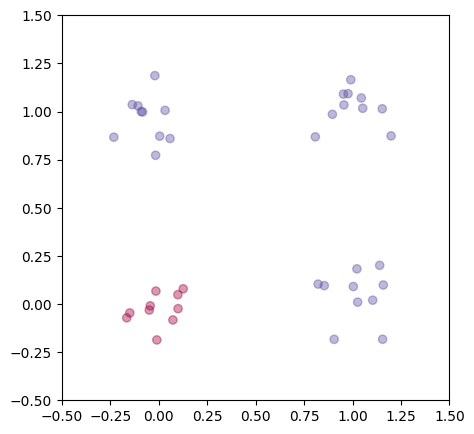

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def plotHyperplan(vector, intercept=0):
  xs = np.array([-0.5,1.5])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

def makeLogicalDataset(n=40, func=lambda a, b: bool(a) or bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0,0],[1,0],[1,1],[0,1]],
                    cluster_std=0.1)
  y = np.array([func(a>0.5, b>0.5) for a, b, in zip(X[:,0], X[:,1])], dtype=int) * 2 - 1
  return X, y

X, y = makeLogicalDataset()
plotDataset(X, y)
plt.show()

Accuracy: 1.0
Weights: [-0.4699042   0.9534361   0.95625177]


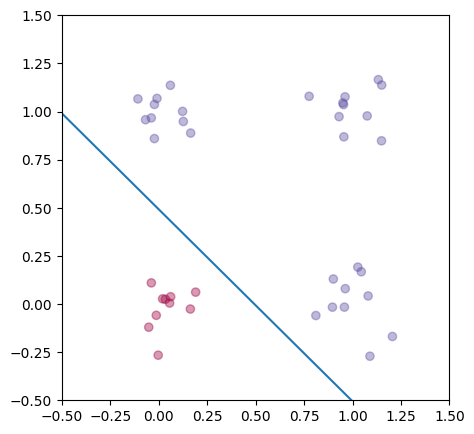

In [ ]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from abc import ABC, abstractstaticmethod

class Cost(ABC):
  @abstractstaticmethod
  def getCost(y, ypred):
    pass
  @abstractstaticmethod
  def getGradient(y, ypred, X):
    pass

class WidrowHoff(Cost):
  @staticmethod
  def getCost(y, ypred):
    return 0.5* ((y-ypred)**2)
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y-ypred)

from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500, cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.n_iter):
      ypred = X @ w
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=GradientDescent()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)

model = NeuralNetwork()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0])
plt.show()

Accuracy: 1.0
Weights: [-1.49601138  0.94239885  0.99368273]


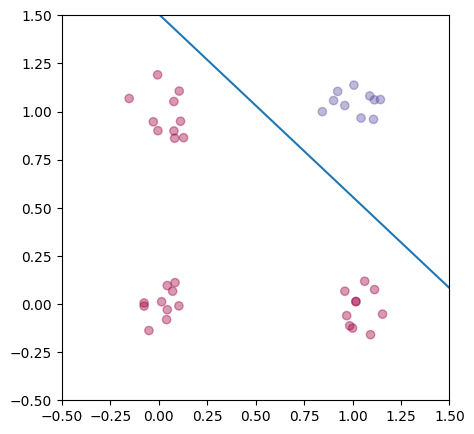

In [ ]:
X, y = makeLogicalDataset(n=40, func=lambda a, b: bool(a) and bool(b))
model = NeuralNetwork()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0])
plt.show()

Accuracy: 0.5
Weights: [ 0.03039926  0.01161455 -0.07293393]


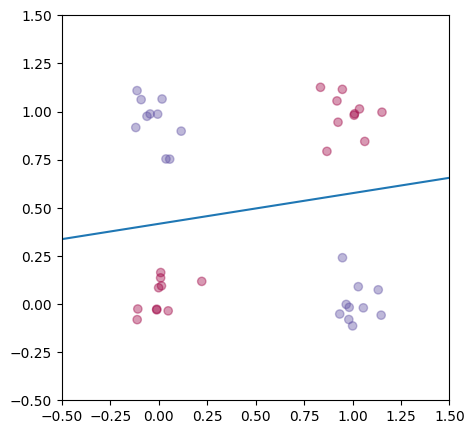

In [ ]:
X, y = makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b))
model = NeuralNetwork()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0])
plt.show()

In [ ]:
class XORClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.ihw = np.array([[0.5, -1, 1], [0.5, 1, -1]])
    self.how = np.array([0.5, -1, -1])
  def predict(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw.T
    self.H = sign(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    ypred = sign(logits)
    return ypred

X, y = makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b))
model = XORClassifier()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")

Accuracy: 1.0


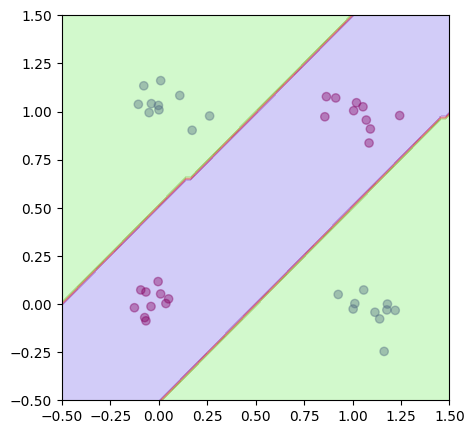

In [ ]:
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)

plotDataset(X, y)
plotPredictions(model, X)
plt.show()

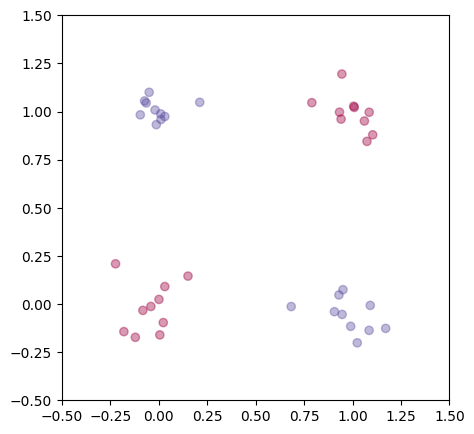

In [ ]:
plotDataset(X, y)
plt.show()

In [ ]:
model = XORClassifier()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")

Accuracy: 1.0


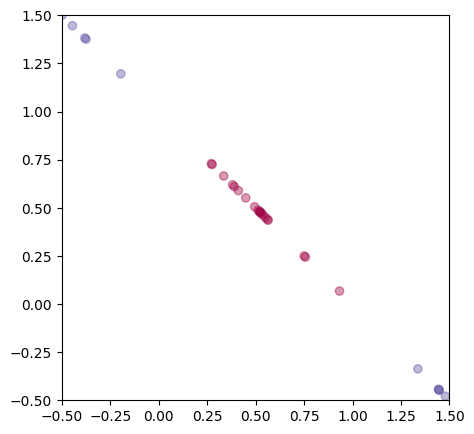

In [ ]:
plotDataset(model.pH, y)
plt.show()

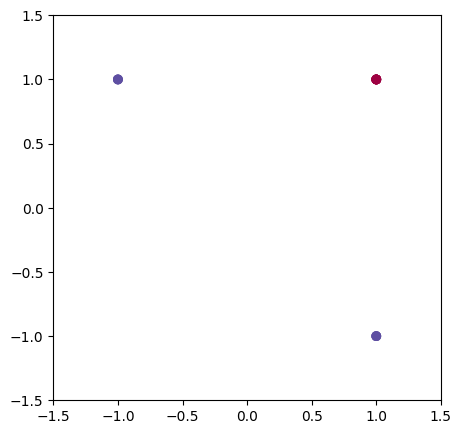

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(model.H[:,0], model.H[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.show()

In [ ]:
from numpy import tanh

class XORClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.ihw = np.array([[0.5, -1, 1], [0.5, 1, -1]])
    self.how = np.array([0.75, -0.9, -0.9])
  def predict(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw.T
    self.H = tanh(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    ypred = sign(logits)
    return ypred

X, y = makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b))
model = XORClassifier()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")

Accuracy: 1.0


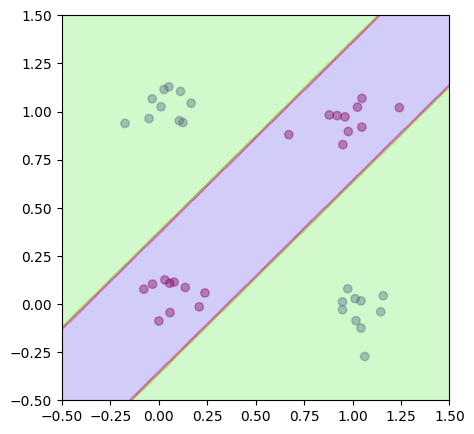

In [ ]:
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

In [ ]:
model = XORClassifier()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")

Accuracy: 1.0


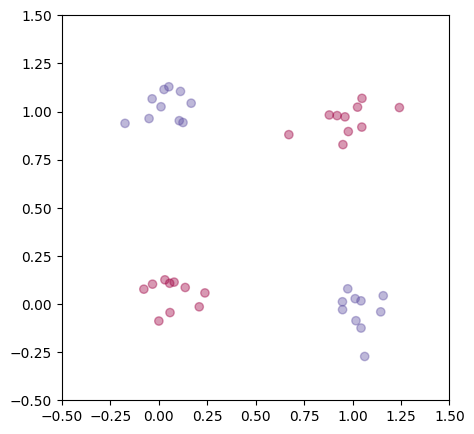

In [ ]:
plotDataset(X, y)
plt.show()

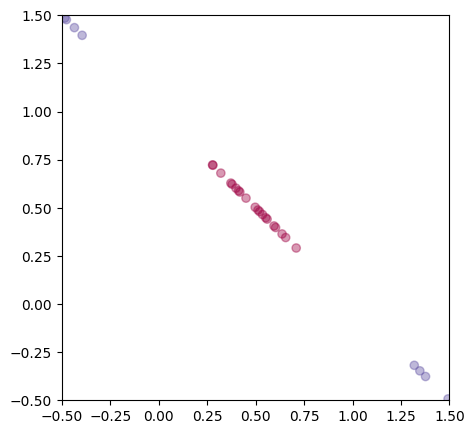

In [ ]:
plotDataset(model.pH, y)
plt.show()

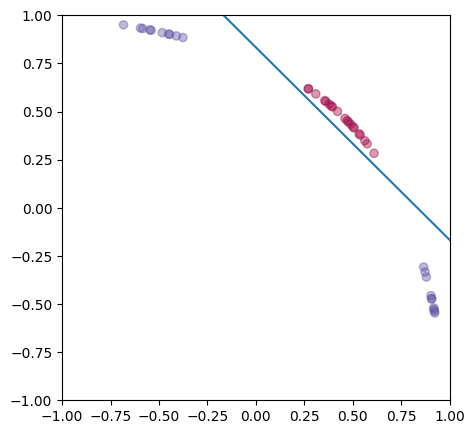

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(model.H[:,0], model.H[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
plt.xlim(-1,1)
plt.ylim(-1,1)
plotHyperplan(model.how[1:], model.how[0])
plt.show()